# Optimisation Scans Testing

In [ ]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis_lean as an
import numpy as np
import matplotlib.pyplot as plt
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import Optimizer


ExpParams = ExpParameterManager()

In [72]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")
slm : SLM = SLM()
hamcam : ImagEMX2Camera = ImagEMX2Camera()

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.
SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.230 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"
ImagEM X2 camera initialised.


In [255]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

motcam.set_trigger_source("bulb")

hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(1200)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

---
## MOT Optimisation
### Find Centre

MOT detected at (x, y): (937, 560)


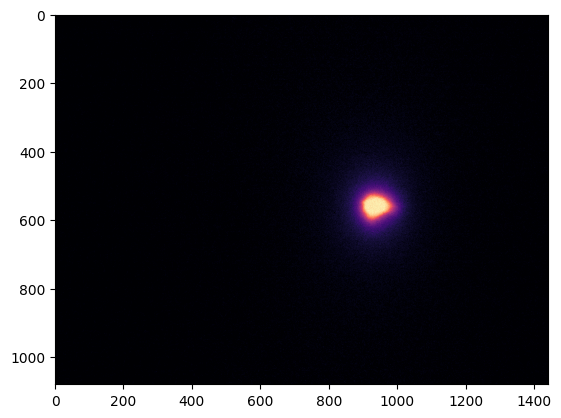

In [260]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma', vmin=0)

try:
    gaussian_params = an.fit_gaussian(img_mean)
    centre_x, centre_y = int(gaussian_params["x0"]), int(gaussian_params["y0"])
    print(f"MOT detected at (x, y): ({centre_x}, {centre_y})")
except Exception as e:
    print(f"Could not detect MOT: {e}")

MOT detected at (x, y): (936, 559)


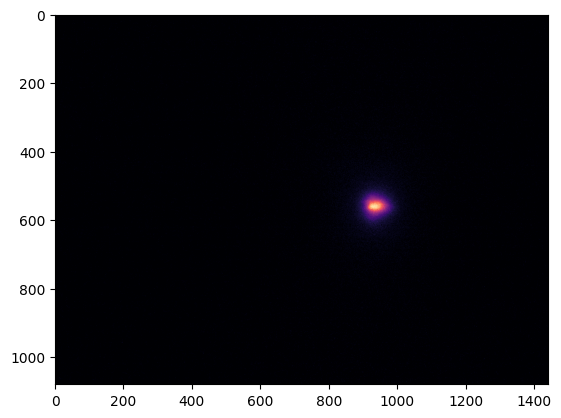

In [75]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma', vmin=0)

try:
    gaussian_params = an.fit_gaussian(img_mean)
    centre_x, centre_y = int(gaussian_params["x0"]), int(gaussian_params["y0"])
    print(f"MOT detected at (x, y): ({centre_x}, {centre_y})")
except Exception as e:
    print(f"Could not detect MOT: {e}")

MOT detected at (x, y): (944, 551)


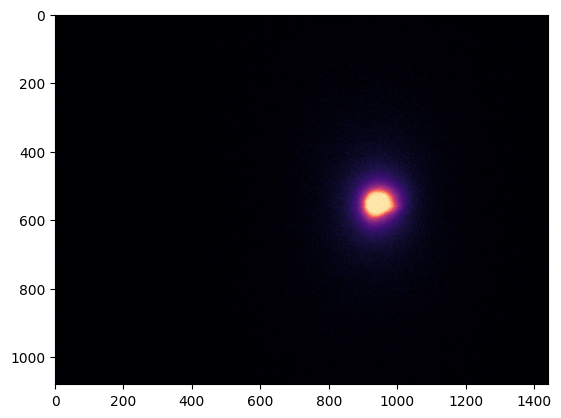

In [54]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
motcam.setup_acquisition(nframes=bg_it)

motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 50000})
imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

exp.set_iterations(img_it)
motcam.setup_acquisition(nframes=img_it)
motcam.start_acquisition()
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
imgs = motcam.acquire_n_frames(nframes=img_it)
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma', vmin=0)

try:
    gaussian_params = an.fit_gaussian(img_mean)
    centre_x, centre_y = int(gaussian_params["x0"]), int(gaussian_params["y0"])
    print(f"MOT detected at (x, y): ({centre_x}, {centre_y})")
except Exception as e:
    print(f"Could not detect MOT: {e}")

    

In [50]:
(556-483) * 1e3 / 194902.8581

0.37454555931932737

### Find Resonances

Scanning cooling VCO...
Iteration 1/20  |  Cooling VCO = 3.000 V, Total Counts = 0.39 E 6
Iteration 2/20  |  Cooling VCO = 3.105 V, Total Counts = 0.43 E 6
Iteration 3/20  |  Cooling VCO = 3.211 V, Total Counts = 0.47 E 6
Iteration 4/20  |  Cooling VCO = 3.316 V, Total Counts = 0.49 E 6
Iteration 5/20  |  Cooling VCO = 3.421 V, Total Counts = 0.57 E 6
Iteration 6/20  |  Cooling VCO = 3.526 V, Total Counts = 0.60 E 6
Iteration 7/20  |  Cooling VCO = 3.632 V, Total Counts = 0.67 E 6
Iteration 8/20  |  Cooling VCO = 3.737 V, Total Counts = 0.76 E 6
Iteration 9/20  |  Cooling VCO = 3.842 V, Total Counts = 0.87 E 6
Iteration 10/20  |  Cooling VCO = 3.947 V, Total Counts = 1.00 E 6
Iteration 11/20  |  Cooling VCO = 4.053 V, Total Counts = 1.15 E 6
Iteration 12/20  |  Cooling VCO = 4.158 V, Total Counts = 1.27 E 6
Iteration 13/20  |  Cooling VCO = 4.263 V, Total Counts = 1.42 E 6
Iteration 14/20  |  Cooling VCO = 4.368 V, Total Counts = 1.54 E 6
Iteration 15/20  |  Cooling VCO = 4.474 V, Tota

Text(0, 0.5, 'Total Counts (a.u.)')

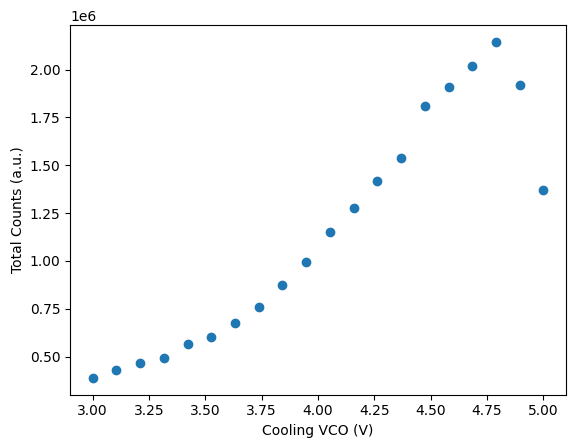

In [ ]:
img_it = 5
bg_it = 2
vco_list = np.linspace(3.0, 5.0, 20)
counts = []

print(f"Scanning cooling VCO...")
for it, vco in enumerate(vco_list):
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"), 
                                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                    "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": vco, 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                    "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": vco, 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = an.get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)
    print(f"Iteration {it+1}/{len(vco_list)}  |  Cooling VCO = {vco:.3f} V, Total Counts = {total_counts/1e6:.2f} E 6")

max_index = np.argmax(counts)
cool_vco_resonance = vco_list[max_index]
print(f"Cooling VCO resonance: {cool_vco_resonance}")

plt.scatter(vco_list, counts)
plt.xlabel("Cooling VCO (V)")
plt.ylabel("Total Counts (a.u.)")

ExpParams.set_parameter("cool_vco_resonance", cool_vco_resonance)


Scanning repump VCO...
Iteration 1/20  |  Repump VCO = 0.000 V, Total Counts = 2.07 E 6
Iteration 2/20  |  Repump VCO = 0.263 V, Total Counts = 2.08 E 6
Iteration 3/20  |  Repump VCO = 0.526 V, Total Counts = 2.05 E 6
Iteration 4/20  |  Repump VCO = 0.789 V, Total Counts = 2.04 E 6
Iteration 5/20  |  Repump VCO = 1.053 V, Total Counts = 2.06 E 6
Iteration 6/20  |  Repump VCO = 1.316 V, Total Counts = 2.10 E 6
Iteration 7/20  |  Repump VCO = 1.579 V, Total Counts = 2.14 E 6
Iteration 8/20  |  Repump VCO = 1.842 V, Total Counts = 2.11 E 6
Iteration 9/20  |  Repump VCO = 2.105 V, Total Counts = 2.11 E 6
Iteration 10/20  |  Repump VCO = 2.368 V, Total Counts = 2.08 E 6
Iteration 11/20  |  Repump VCO = 2.632 V, Total Counts = 2.12 E 6
Iteration 12/20  |  Repump VCO = 2.895 V, Total Counts = 2.09 E 6
Iteration 13/20  |  Repump VCO = 3.158 V, Total Counts = 2.04 E 6
Iteration 14/20  |  Repump VCO = 3.421 V, Total Counts = 2.10 E 6
Iteration 15/20  |  Repump VCO = 3.684 V, Total Counts = 2.12 

Text(0, 0.5, 'Total Counts (a.u.)')

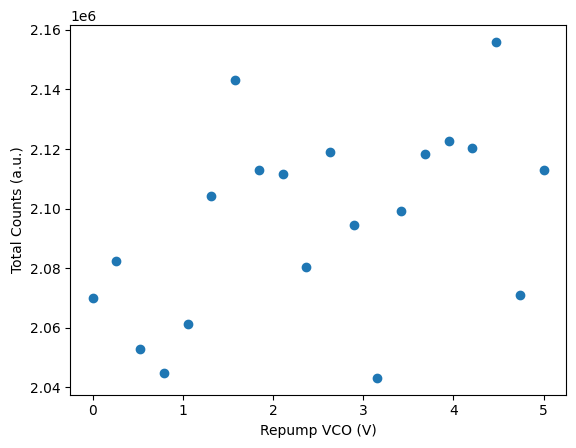

In [ ]:
img_it = 5
bg_it = 2
vco_list = np.linspace(0.0, 5.0, 20)
counts = []

print(f"Scanning repump VCO...")
for it, vco in enumerate(vco_list):
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"), 
                                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                    "tImgRepVCO1": vco, "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"), 
                                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                    "tImgRepVCO1": vco, "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = an.get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)
    print(f"Iteration {it+1}/{len(vco_list)}  |  Repump VCO = {vco:.3f} V, Total Counts = {total_counts/1e6:.2f} E 6")

max_index = np.argmax(counts)
rep_vco_resonance = vco_list[max_index]
print(f"Repump VCO resonance: {rep_vco_resonance}")

plt.scatter(vco_list, counts)
plt.xlabel("Repump VCO (V)")
plt.ylabel("Total Counts (a.u.)")

ExpParams.set_parameter("rep_vco_resonance", rep_vco_resonance)


### MOT Number 

Scanning MOT cooling VCO...
Iteration 1/20  |  MOT Cooling VCO = 3.000 V, Total Counts = 0.23 E 6
Iteration 2/20  |  MOT Cooling VCO = 3.105 V, Total Counts = 0.31 E 6
Iteration 3/20  |  MOT Cooling VCO = 3.211 V, Total Counts = 0.47 E 6
Iteration 4/20  |  MOT Cooling VCO = 3.316 V, Total Counts = 0.62 E 6
Iteration 5/20  |  MOT Cooling VCO = 3.421 V, Total Counts = 0.87 E 6
Iteration 6/20  |  MOT Cooling VCO = 3.526 V, Total Counts = 1.14 E 6
Iteration 7/20  |  MOT Cooling VCO = 3.632 V, Total Counts = 1.42 E 6
Iteration 8/20  |  MOT Cooling VCO = 3.737 V, Total Counts = 1.51 E 6
Iteration 9/20  |  MOT Cooling VCO = 3.842 V, Total Counts = 1.78 E 6
Iteration 10/20  |  MOT Cooling VCO = 3.947 V, Total Counts = 1.82 E 6
Iteration 11/20  |  MOT Cooling VCO = 4.053 V, Total Counts = 1.96 E 6
Iteration 12/20  |  MOT Cooling VCO = 4.158 V, Total Counts = 2.11 E 6
Iteration 13/20  |  MOT Cooling VCO = 4.263 V, Total Counts = 2.15 E 6
Iteration 14/20  |  MOT Cooling VCO = 4.368 V, Total Count

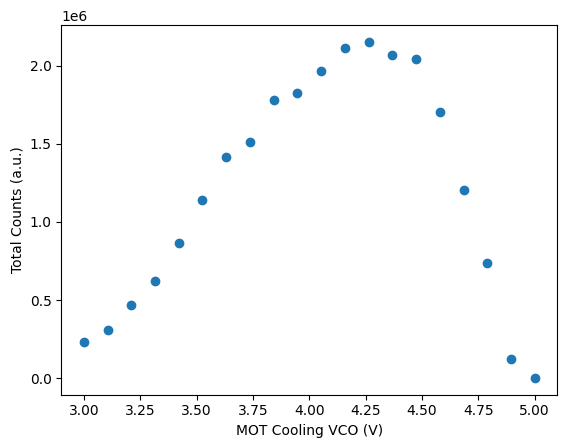

In [ ]:
img_it = 5
bg_it = 2
vco_list = np.linspace(3.0, 5.0, 20)
counts = []

print(f"Scanning MOT cooling VCO...")
for it, vco in enumerate(vco_list):
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": vco, 
                                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                    "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": vco, 
                                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                    "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = an.get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)
    print(f"Iteration {it+1}/{len(vco_list)}  |  MOT Cooling VCO = {vco:.3f} V, Total Counts = {total_counts/1e6:.2f} E 6")

max_index = np.argmax(counts)
cool_vco_max = vco_list[max_index]
print(f"MOT Cooling VCO resonance: {cool_vco_max}")

plt.scatter(vco_list, counts)
plt.xlabel("MOT Cooling VCO (V)")
plt.ylabel("Total Counts (a.u.)")

ExpParams.set_parameter("tMOTLoadCoolVCO", cool_vco_max)

Scanning MOT repump VCO...
Iteration 1/20  |  MOT Repump VCO = 0.000 V, Total Counts = 2.12 E 6
Iteration 2/20  |  MOT Repump VCO = 0.263 V, Total Counts = 2.19 E 6
Iteration 3/20  |  MOT Repump VCO = 0.526 V, Total Counts = 2.15 E 6
Iteration 4/20  |  MOT Repump VCO = 0.789 V, Total Counts = 2.14 E 6
Iteration 5/20  |  MOT Repump VCO = 1.053 V, Total Counts = 2.16 E 6
Iteration 6/20  |  MOT Repump VCO = 1.316 V, Total Counts = 2.20 E 6
Iteration 7/20  |  MOT Repump VCO = 1.579 V, Total Counts = 2.20 E 6
Iteration 8/20  |  MOT Repump VCO = 1.842 V, Total Counts = 2.22 E 6
Iteration 9/20  |  MOT Repump VCO = 2.105 V, Total Counts = 2.13 E 6
Iteration 10/20  |  MOT Repump VCO = 2.368 V, Total Counts = 2.17 E 6
Iteration 11/20  |  MOT Repump VCO = 2.632 V, Total Counts = 2.16 E 6
Iteration 12/20  |  MOT Repump VCO = 2.895 V, Total Counts = 2.12 E 6
Iteration 13/20  |  MOT Repump VCO = 3.158 V, Total Counts = 2.21 E 6
Iteration 14/20  |  MOT Repump VCO = 3.421 V, Total Counts = 2.17 E 6
It

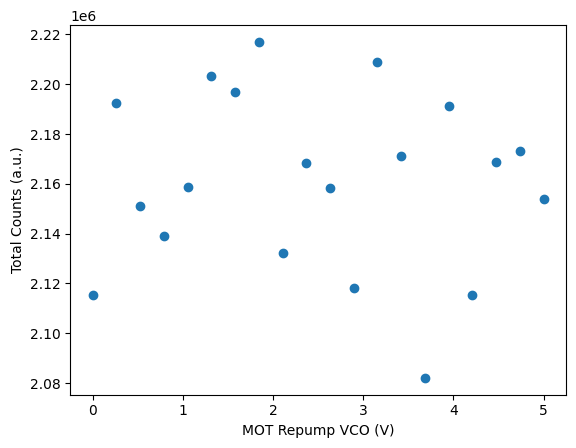

In [ ]:
img_it = 5
bg_it = 2
vco_list = np.linspace(0.0, 5.0, 20)
counts = []

print(f"Scanning MOT repump VCO...")
for it, vco in enumerate(vco_list):
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": vco, "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                    "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": vco, "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                    "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = an.get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)
    print(f"Iteration {it+1}/{len(vco_list)}  |  MOT Repump VCO = {vco:.3f} V, Total Counts = {total_counts/1e6:.2f} E 6")

max_index = np.argmax(counts)
rep_vco_max = vco_list[max_index]
print(f"MOT Repump VCO resonance: {rep_vco_max}")

plt.scatter(vco_list, counts)
plt.xlabel("MOT Repump VCO (V)")
plt.ylabel("Total Counts (a.u.)")

ExpParams.set_parameter("tMOTLoadRepVCO", rep_vco_max)

Scanning MOT cooling VVA...
Iteration 1/20  |  MOT Cooling VVA = 0.400 V, Total Counts = -0.00 E 6
Iteration 2/20  |  MOT Cooling VVA = 0.458 V, Total Counts = 0.24 E 6
Iteration 3/20  |  MOT Cooling VVA = 0.516 V, Total Counts = 0.40 E 6
Iteration 4/20  |  MOT Cooling VVA = 0.574 V, Total Counts = 0.39 E 6
Iteration 5/20  |  MOT Cooling VVA = 0.632 V, Total Counts = 0.74 E 6
Iteration 6/20  |  MOT Cooling VVA = 0.689 V, Total Counts = 1.64 E 6
Iteration 7/20  |  MOT Cooling VVA = 0.747 V, Total Counts = 2.08 E 6
Iteration 8/20  |  MOT Cooling VVA = 0.805 V, Total Counts = 2.28 E 6
Iteration 9/20  |  MOT Cooling VVA = 0.863 V, Total Counts = 2.20 E 6
Iteration 10/20  |  MOT Cooling VVA = 0.921 V, Total Counts = 2.30 E 6
Iteration 11/20  |  MOT Cooling VVA = 0.979 V, Total Counts = 2.26 E 6
Iteration 12/20  |  MOT Cooling VVA = 1.037 V, Total Counts = 2.13 E 6
Iteration 13/20  |  MOT Cooling VVA = 1.095 V, Total Counts = 2.20 E 6
Iteration 14/20  |  MOT Cooling VVA = 1.153 V, Total Coun

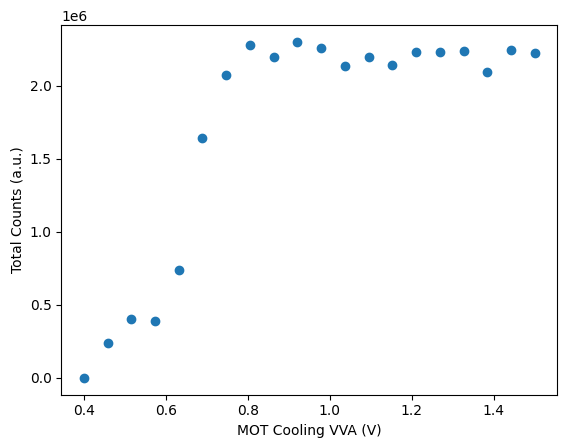

In [24]:
img_it = 5
bg_it = 2
vva_list = np.linspace(0.4, 1.5, 20)
counts = []

print(f"Scanning MOT cooling VVA...")
for it, vva in enumerate(vva_list):
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": vva,
                                    "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": vva,
                                    "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = an.get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)
    print(f"Iteration {it+1}/{len(vva_list)}  |  MOT Cooling VVA = {vva:.3f} V, Total Counts = {total_counts/1e6:.2f} E 6")

max_index = np.argmax(counts)
cool_vva_max = vva_list[max_index]
print(f"MOT Cooling VVA resonance: {cool_vva_max}")

plt.scatter(vva_list, counts)
plt.xlabel("MOT Cooling VVA (V)")
plt.ylabel("Total Counts (a.u.)")

ExpParams.set_parameter("tMOTLoadCoolVVA", cool_vva_max)

Scanning MOT repump VVA...
Iteration 1/20  |  MOT Repump VVA = 0.400 V, Total Counts = 2.05 E 6
Iteration 2/20  |  MOT Repump VVA = 0.432 V, Total Counts = 2.15 E 6
Iteration 3/20  |  MOT Repump VVA = 0.463 V, Total Counts = 2.15 E 6
Iteration 4/20  |  MOT Repump VVA = 0.495 V, Total Counts = 2.24 E 6
Iteration 5/20  |  MOT Repump VVA = 0.526 V, Total Counts = 2.10 E 6
Iteration 6/20  |  MOT Repump VVA = 0.558 V, Total Counts = 2.20 E 6
Iteration 7/20  |  MOT Repump VVA = 0.589 V, Total Counts = 2.24 E 6
Iteration 8/20  |  MOT Repump VVA = 0.621 V, Total Counts = 2.23 E 6
Iteration 9/20  |  MOT Repump VVA = 0.653 V, Total Counts = 2.26 E 6
Iteration 10/20  |  MOT Repump VVA = 0.684 V, Total Counts = 2.20 E 6
Iteration 11/20  |  MOT Repump VVA = 0.716 V, Total Counts = 2.18 E 6
Iteration 12/20  |  MOT Repump VVA = 0.747 V, Total Counts = 2.26 E 6
Iteration 13/20  |  MOT Repump VVA = 0.779 V, Total Counts = 2.21 E 6
Iteration 14/20  |  MOT Repump VVA = 0.811 V, Total Counts = 2.20 E 6
It

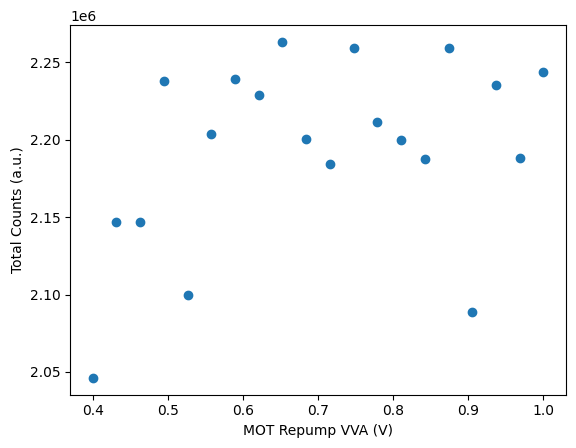

In [25]:
img_it = 5
bg_it = 2
vva_list = np.linspace(0.4, 1.0, 20)
counts = []

print(f"Scanning MOT repump VVA...")
for it, vva in enumerate(vva_list):
    exp.set_iterations(bg_it)
    motcam.setup_acquisition(nframes=bg_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                    "tMOTLoadRepVVA": vva, "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                    "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs_bg = motcam.acquire_n_frames(nframes=bg_it)

    exp.set_iterations(img_it)
    motcam.setup_acquisition(nframes=img_it)
    motcam.start_acquisition()
    exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                    "tMOTLoadRepVVA": vva, "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                                    "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                    "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 4.0, "tImgRepVVA1": 4.0, "tDelay2": 1, 
                                    "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 25000})
    imgs = motcam.acquire_n_frames(nframes=img_it)
    img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)
    total_counts = an.get_total_counts(img_mean, centre_x, centre_y, window_size=50)
    counts.append(total_counts)
    print(f"Iteration {it+1}/{len(vva_list)}  |  MOT Repump VVA = {vva:.3f} V, Total Counts = {total_counts/1e6:.2f} E 6")

max_index = np.argmax(counts)
rep_vva_max = vva_list[max_index]
print(f"MOT Repump VVA resonance: {rep_vva_max}")

plt.scatter(vva_list, counts)
plt.xlabel("MOT Repump VVA (V)")
plt.ylabel("Total Counts (a.u.)")

ExpParams.set_parameter("tMOTLoadRepVVA", rep_vva_max)

---
## Tweezer Optimisation

In [82]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

W1 = np.ones((10,10))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um
--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.35e-05 | Uniformity: 56.39% | Min/Max ratio: 0.061
Iteration 010 | Mean-Squared Error: 1.21e-07 | Uniformity: 83.97% | Min/Max ratio: 0.530
Iteration 020 | Mean-Squared Error: 2.26e-08 | Uniformity: 83.48% | Min/Max ratio: 0.519
Iteration 030 | Mean-Squared Error: 5.93e-09 | Uniformity: 83.51% | Min/Max ratio: 0.530
Iteration 040 | Mean-Squared Error: 1.21e-08 | Uniformity: 83.46% | Min/Max ratio: 0.527
Iteration 050 | Mean-Squared Error: 4.70e-09 | Uniformity: 83.54% | Min/Max ratio: 0.530
Iteration 060 | Mean-Squared Er

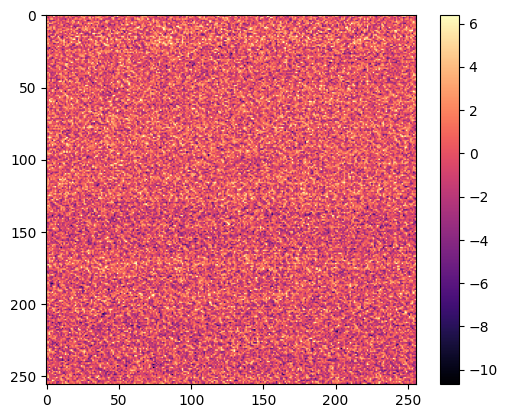

In [311]:
# Experiment and camera setup
n_iterations = 200
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
10x10 array detected.


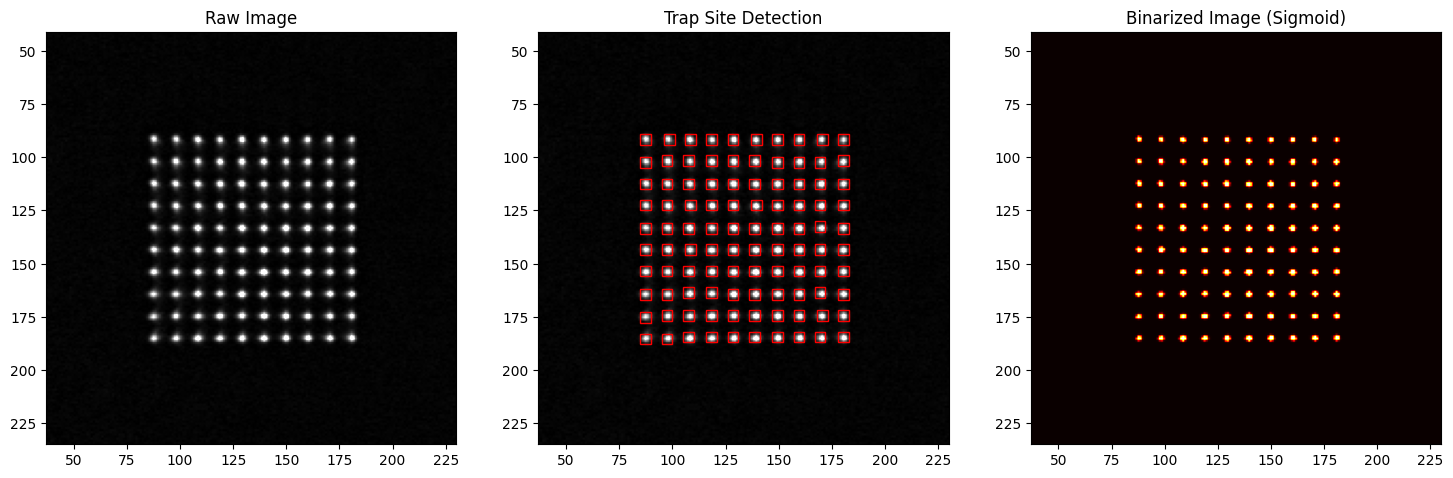

Trap (0, 0) Loading Probability : 55.40 %
Trap (0, 1) Loading Probability : 55.50 %
Trap (0, 2) Loading Probability : 55.80 %
Trap (0, 3) Loading Probability : 58.60 %
Trap (0, 4) Loading Probability : 56.60 %
Trap (0, 5) Loading Probability : 55.70 %
Trap (0, 6) Loading Probability : 56.90 %
Trap (0, 7) Loading Probability : 54.50 %
Trap (0, 8) Loading Probability : 57.10 %
Trap (0, 9) Loading Probability : 51.40 %
Trap (1, 0) Loading Probability : 56.20 %
Trap (1, 1) Loading Probability : 56.90 %
Trap (1, 2) Loading Probability : 56.50 %
Trap (1, 3) Loading Probability : 52.70 %
Trap (1, 4) Loading Probability : 58.20 %
Trap (1, 5) Loading Probability : 51.60 %
Trap (1, 6) Loading Probability : 56.60 %
Trap (1, 7) Loading Probability : 57.30 %
Trap (1, 8) Loading Probability : 54.90 %
Trap (1, 9) Loading Probability : 55.10 %
Trap (2, 0) Loading Probability : 57.20 %
Trap (2, 1) Loading Probability : 56.60 %
Trap (2, 2) Loading Probability : 56.60 %
Trap (2, 3) Loading Probability : 

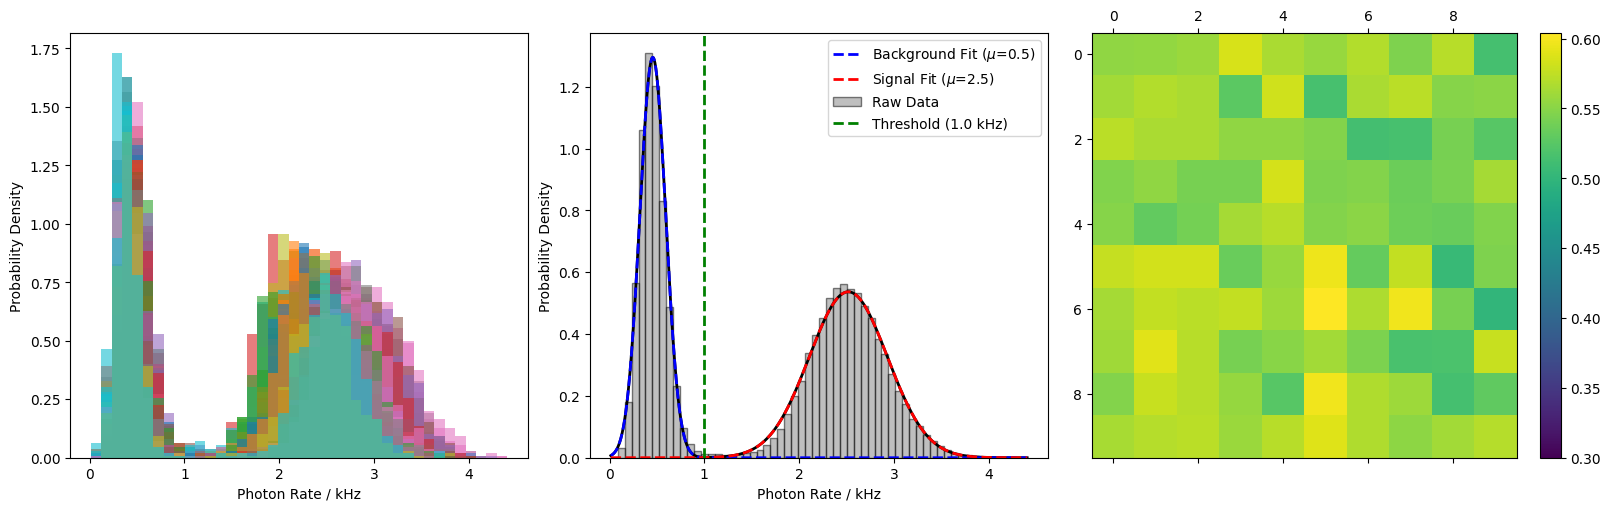

In [306]:
array_shape = [10, 10]
window = 5
feature_size = 10

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape, detection_step=200)
an.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)

In [308]:
fidelity*100

np.float64(99.99188594727904)

Trap (0, 0) Loading Probability : 50.00 %
Trap (0, 1) Loading Probability : 61.00 %
Trap (0, 2) Loading Probability : 52.00 %
Trap (0, 3) Loading Probability : 58.00 %
Trap (0, 4) Loading Probability : 61.00 %
Trap (0, 5) Loading Probability : 52.00 %
Trap (0, 6) Loading Probability : 67.00 %
Trap (0, 7) Loading Probability : 46.00 %
Trap (0, 8) Loading Probability : 54.00 %
Trap (0, 9) Loading Probability : 53.00 %
Trap (1, 0) Loading Probability : 64.00 %
Trap (1, 1) Loading Probability : 56.00 %
Trap (1, 2) Loading Probability : 53.00 %
Trap (1, 3) Loading Probability : 48.00 %
Trap (1, 4) Loading Probability : 58.00 %
Trap (1, 5) Loading Probability : 44.00 %
Trap (1, 6) Loading Probability : 64.00 %
Trap (1, 7) Loading Probability : 62.00 %
Trap (1, 8) Loading Probability : 49.00 %
Trap (1, 9) Loading Probability : 56.00 %
Trap (2, 0) Loading Probability : 56.00 %
Trap (2, 1) Loading Probability : 59.00 %
Trap (2, 2) Loading Probability : 66.00 %
Trap (2, 3) Loading Probability : 

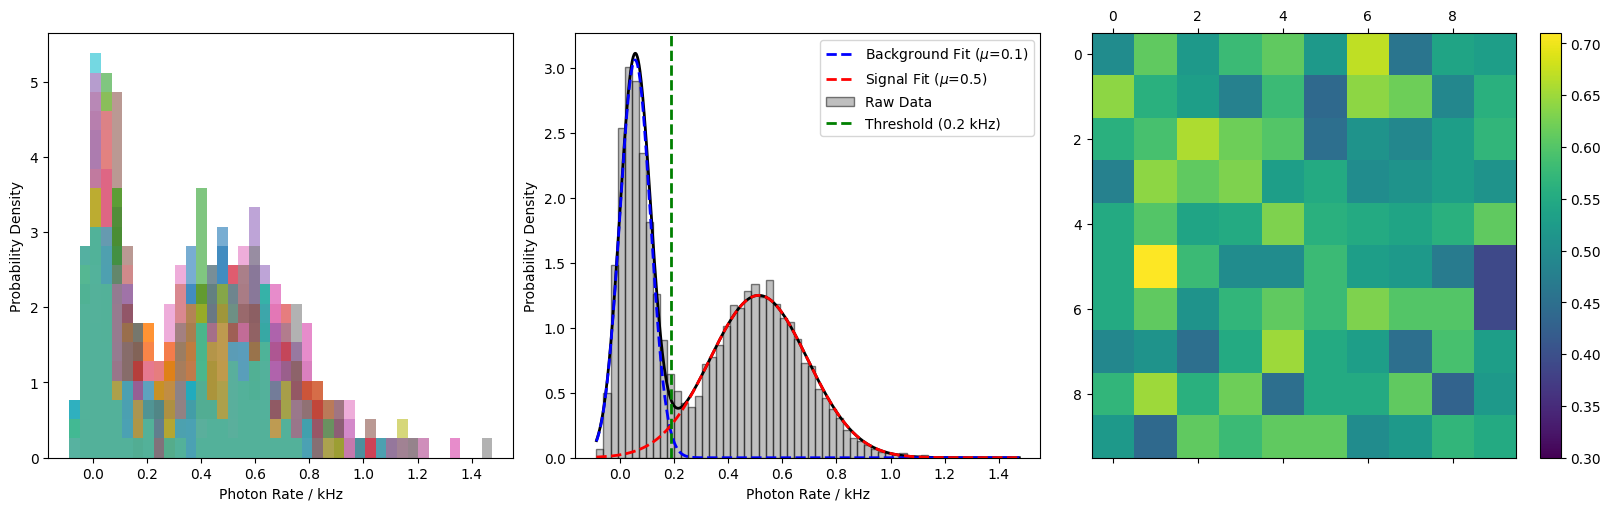

In [277]:
imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
photon_rates, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)
survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions, array_shape, window_size=window)
print(f"Survival probability: {survival_probability*100:.4f} %")

In [303]:
# Experiment and camera setup
n_iterations = 20
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

vco_list = np.linspace(0.0, 5.0, 40)
surv_list, loading_list, fidelity_list = [], [], []

for vco in vco_list:
    ExpParams.set_parameter("tImgCoolVCO", vco)
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
        "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
        "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
        "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
        "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
        "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
        "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
        "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
        "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
        "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
        "BackgroundDrop": 0})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
    photon_rates, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60, verbose=False, show_histogram=False)
    survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions, array_shape, window_size=window)
    mean_loading_probability = np.mean(loading_probabilities)

    surv_list.append(survival_probability)
    loading_list.append(mean_loading_probability)
    fidelity_list.append(fidelity)

    print(f"Cooling VCO: {vco:.3f} V, Mean Loading Probability: {mean_loading_probability*100:.4f} %, Survival Probability: {survival_probability*100:.4f} %, Detection Fidelity: {fidelity*100:.4f} %")

Parameter 'tImgCoolVCO' set to 0.0.
Cooling VCO: 0.000 V, Mean Loading Probability: 47.4000 %, Survival Probability: 64.0677 %, Detection Fidelity: 85.5030 %
Parameter 'tImgCoolVCO' set to 0.1282051282051282.
Cooling VCO: 0.128 V, Mean Loading Probability: 47.7000 %, Survival Probability: 72.7684 %, Detection Fidelity: 85.6411 %
Parameter 'tImgCoolVCO' set to 0.2564102564102564.
Cooling VCO: 0.256 V, Mean Loading Probability: 45.2000 %, Survival Probability: 72.2710 %, Detection Fidelity: 87.0918 %
Parameter 'tImgCoolVCO' set to 0.3846153846153846.
Cooling VCO: 0.385 V, Mean Loading Probability: 53.5000 %, Survival Probability: 76.1214 %, Detection Fidelity: 87.9165 %
Parameter 'tImgCoolVCO' set to 0.5128205128205128.
Cooling VCO: 0.513 V, Mean Loading Probability: 47.7500 %, Survival Probability: 79.0443 %, Detection Fidelity: 89.1174 %
Parameter 'tImgCoolVCO' set to 0.641025641025641.
Cooling VCO: 0.641 V, Mean Loading Probability: 54.7000 %, Survival Probability: 76.0523 %, Detectio

Optimal Cooling VCO: 3.333 V, Survival Probability: 94.8796 %, Loading Probability: 56.2500 %, Detection Fidelity: 99.9952 %
Parameter 'tImgCoolVCO' set to 3.333333333333333.


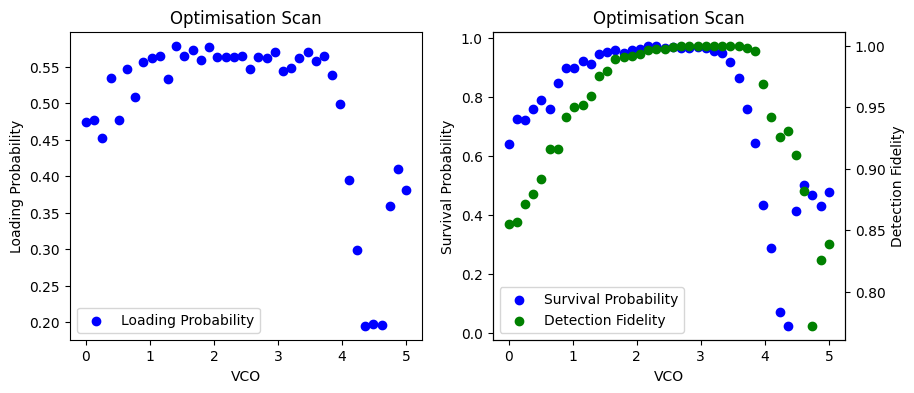

In [304]:
# Plot the loading probability vs vco in one plot and in a second plot plot the survival probability and detection fidelity vs vco in the same plot with different y axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.scatter(vco_list, loading_list, label="Loading Probability", color="blue")
ax1.set_xlabel("VCO")
ax1.set_ylabel("Loading Probability")
ax1.set_title("Optimisation Scan")
ax1.legend()

# Create a second y-axis for the right plot
ax2_right = ax2.twinx()
ax2.scatter(vco_list, surv_list, label="Survival Probability", color="blue")
ax2_right.scatter(vco_list, fidelity_list, label="Detection Fidelity", color="green")

# Set labels and titles
ax2.set_xlabel("VCO")
ax2.set_ylabel("Survival Probability")
ax2_right.set_ylabel("Detection Fidelity")
ax2.set_title("Optimisation Scan")

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2)

max_index_ = np.argmax(surv_list)

print(f"Optimal Cooling VCO: {vco_list[max_index]:.3f} V, Survival Probability: {surv_list[max_index]*100:.4f} %, Loading Probability: {loading_list[max_index]*100:.4f} %, Detection Fidelity: {fidelity_list[max_index]*100:.4f} %")

ExpParams.set_parameter("tImgCoolVCO", vco_list[max_index])

---

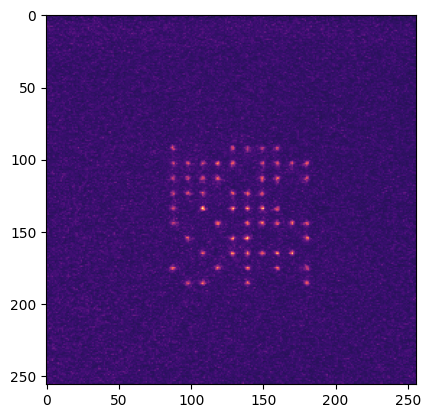

In [229]:
plt.imshow(imgs1[500], cmap='magma', vmin=0, vmax=imgs1[500].max())

mu_10 = np.mean(imgs2, axis=(0, 1, 2))
std_10 = np.std(imgs2, axis=(0, 1, 2))
snr_10 = mu_10 / std_10

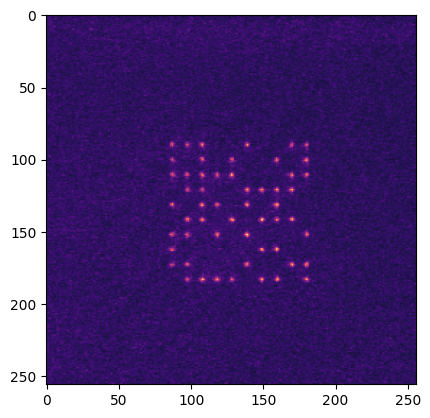

In [230]:
plt.imshow(imgs_25[0], cmap='magma', vmin=0, vmax=imgs_25[0].max())

# Calculate the mean of all the images in imgs_25
mu_25 = np.mean(bgs_25, axis=(0, 1, 2))
std_25 = np.std(bgs_25, axis=(0, 1, 2))
snr_25 = mu_25 / std_25

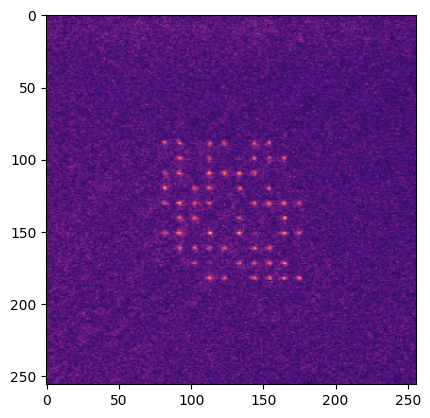

In [231]:
plt.imshow(imgs_50[0], cmap='magma', vmin=0, vmax=imgs_50[0].max())

# Calculate the mean of all the images in imgs_50
mu_50 = np.mean(bgs_50, axis=(0, 1, 2))
std_50 = np.std(bgs_50, axis=(0, 1, 2))
snr_50 = mu_50 / std_50

C:\Users\tweez\AppData\Local\Temp\ipykernel_37640\2683834419.py:8: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
C:\Users\tweez\AppData\Local\Temp\ipykernel_37640\2683834419.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exponential_func, expo_times, snr_arrays)
C:\Users\tweez\AppData\Local\Temp\ipykernel_37640\2683834419.py:17: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_1, pcov_1 = curve_fit(power_func, expo_times, snr_arrays)
C:\Users\tweez\AppData\Local\Temp\ipykernel_37640\2683834419.py:11: RuntimeWarning: divide by zero encountered in power
  return a * x ** (-1/b) + c


(5.6, 7.6)

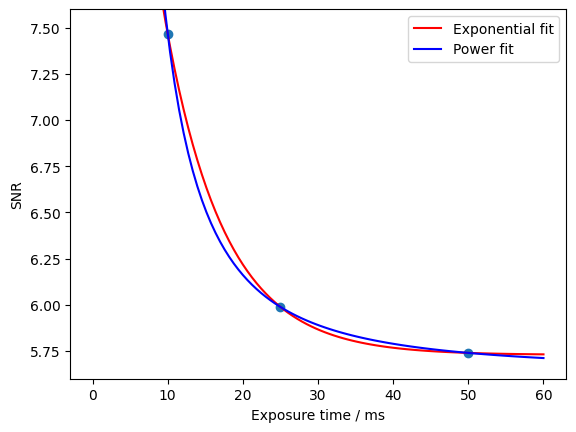

In [243]:
from scipy.optimize import curve_fit

expo_times = [10, 25, 50]
snr_arrays = [snr_10, snr_25, snr_50]

# Fit an exponential to this data
def exponential_func(x, a, b, c):
    return a * np.exp(-b * x) + c

def power_func(x, a, b, c):
    return a * x ** (-1/b) + c

popt, pcov = curve_fit(exponential_func, expo_times, snr_arrays)
x_fit = np.linspace(0, 60, 100)
y_fit = exponential_func(x_fit, *popt)

popt_1, pcov_1 = curve_fit(power_func, expo_times, snr_arrays)
x_fit_1 = np.linspace(0, 60, 100)
y_fit_1 = power_func(x_fit_1, *popt_1)

plt.scatter(expo_times, snr_arrays)
plt.plot(x_fit, y_fit, 'r-', label='Exponential fit')
plt.plot(x_fit_1, y_fit_1, 'b-', label='Power fit')
plt.xlabel("Exposure time / ms")
plt.ylabel("SNR")
plt.legend()
plt.ylim(5.6, 7.60)

[np.float64(2483.5764901428224),
 np.float64(3270.846459686279),
 np.float64(4026.4066199645995)]

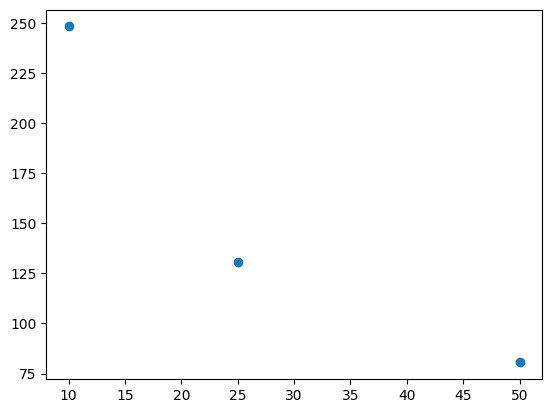

In [251]:
plt.scatter(expo_times, [mu_10/10, mu_25/25, mu_50/50])
[mu_10, mu_25, mu_50]

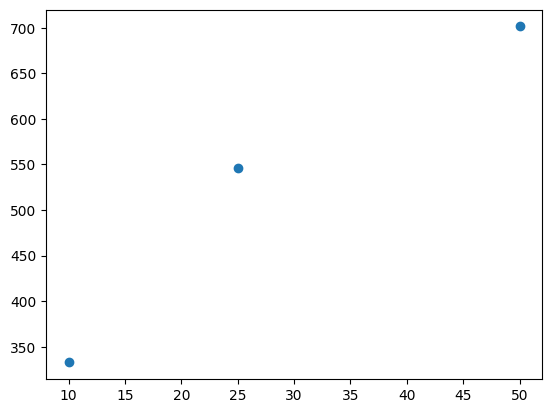

In [249]:
plt.scatter(expo_times, [std_10, std_25, std_50])

In [247]:
popt_1

array([117.59345705,   0.55275977,   5.64045205])

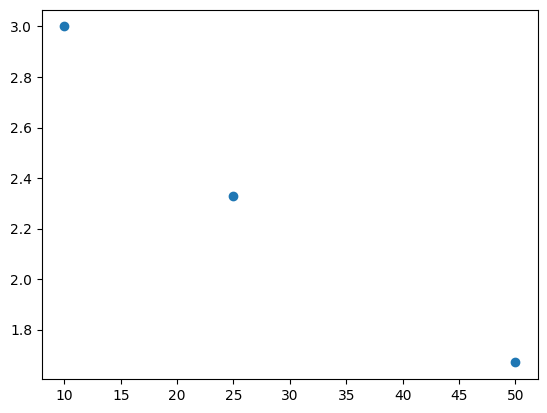

In [246]:
vco_list = [3.00, 2.33, 1.67]
plt.scatter(expo_times, vco_list)

In [202]:
img_50_dir = "C:\\Users\\tweez\\ColdMatter\\pytweezer\\Image Data\\50ms expo images\\"
bg_50_dir = "C:\\Users\\tweez\\ColdMatter\\pytweezer\\Image Data\\50ms expo backgrounds\\"

imgs_50 = []
bgs_50 = []
for i in range(len(imgs1)):
    img_filename = f"{img_50_dir}/image_{i:04d}.tif"
    bg_filename = f"{bg_50_dir}/image_{i:04d}.tif"
    img_ = tifffile.imread(img_filename)
    bg_ = tifffile.imread(bg_filename)
    imgs_50.append(img_)
    bgs_50.append(bg_)

In [205]:
img_25_dir = "C:\\Users\\tweez\\ColdMatter\\pytweezer\\Image Data\\25ms expo images\\"
bg_25_dir = "C:\\Users\\tweez\\ColdMatter\\pytweezer\\Image Data\\25ms expo backgrounds\\"

imgs_25 = []
bgs_25 = []
for i in range(len(imgs1)):
    img_filename = f"{img_25_dir}/image_{i:04d}.tif"
    bg_filename = f"{bg_25_dir}/image_{i:04d}.tif"
    img_ = tifffile.imread(img_filename)
    bg_ = tifffile.imread(bg_filename)
    imgs_25.append(img_)
    bgs_25.append(bg_)

Looking for trap sites...
10x10 array detected.


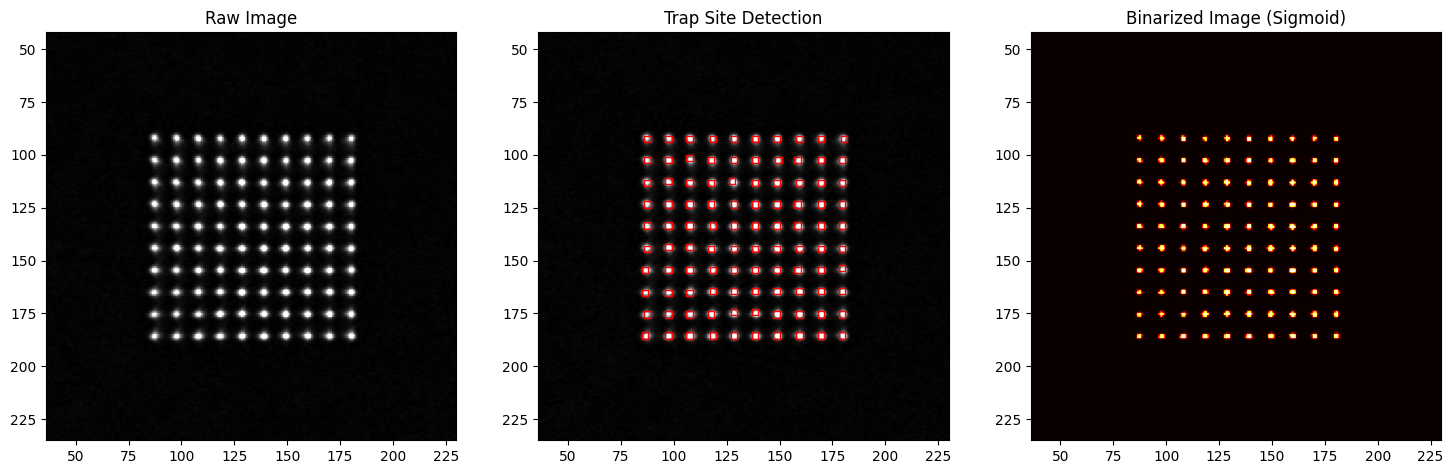

Trap (0, 0) Loading Probability : 54.00 %
Trap (0, 1) Loading Probability : 58.40 %
Trap (0, 2) Loading Probability : 57.00 %
Trap (0, 3) Loading Probability : 57.20 %
Trap (0, 4) Loading Probability : 54.30 %
Trap (0, 5) Loading Probability : 58.60 %
Trap (0, 6) Loading Probability : 58.30 %
Trap (0, 7) Loading Probability : 53.80 %
Trap (0, 8) Loading Probability : 54.20 %
Trap (0, 9) Loading Probability : 53.80 %
Trap (1, 0) Loading Probability : 57.30 %
Trap (1, 1) Loading Probability : 56.60 %
Trap (1, 2) Loading Probability : 56.30 %
Trap (1, 3) Loading Probability : 56.00 %
Trap (1, 4) Loading Probability : 56.30 %
Trap (1, 5) Loading Probability : 54.80 %
Trap (1, 6) Loading Probability : 54.90 %
Trap (1, 7) Loading Probability : 56.90 %
Trap (1, 8) Loading Probability : 54.30 %
Trap (1, 9) Loading Probability : 54.50 %
Trap (2, 0) Loading Probability : 56.20 %
Trap (2, 1) Loading Probability : 56.30 %
Trap (2, 2) Loading Probability : 54.40 %
Trap (2, 3) Loading Probability : 

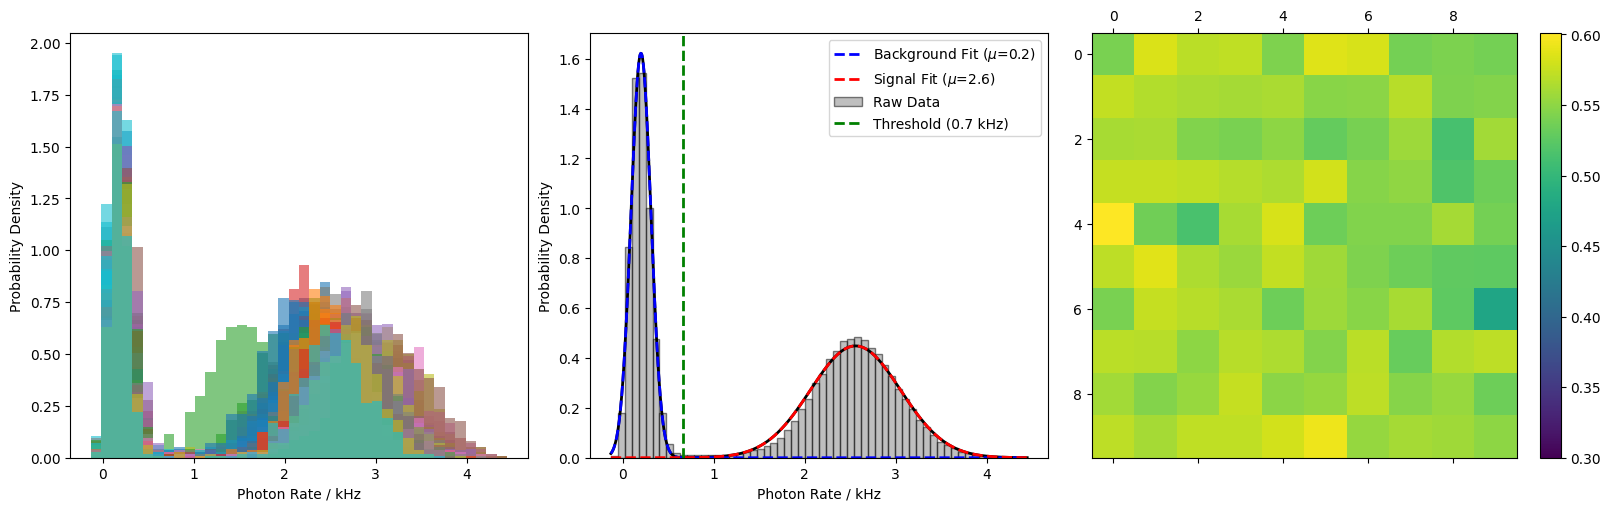

In [174]:
array_shape = [10, 10]
window = 3
feature_size = 10

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape, detection_step=100)
an.visualize_results(filtered_img_average, grid_positions, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)

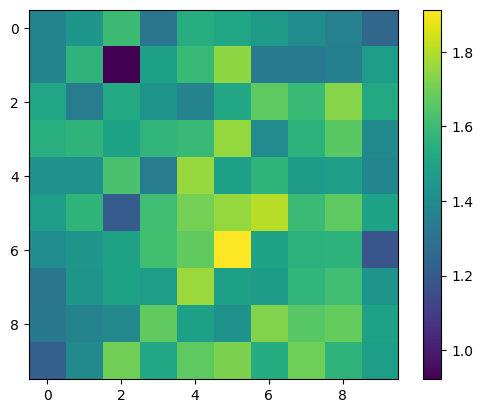

In [179]:
plt.imshow(photon_rates.mean(axis=0))
plt.colorbar()

Trap (0, 0) Loading Probability : 56.00 %
Trap (0, 1) Loading Probability : 43.00 %
Trap (0, 2) Loading Probability : 49.00 %
Trap (0, 3) Loading Probability : 51.00 %
Trap (0, 4) Loading Probability : 66.00 %
Trap (0, 5) Loading Probability : 56.00 %
Trap (0, 6) Loading Probability : 56.00 %
Trap (0, 7) Loading Probability : 59.00 %
Trap (0, 8) Loading Probability : 54.00 %
Trap (0, 9) Loading Probability : 46.00 %
Trap (1, 0) Loading Probability : 55.00 %
Trap (1, 1) Loading Probability : 62.00 %
Trap (1, 2) Loading Probability : 57.00 %
Trap (1, 3) Loading Probability : 47.00 %
Trap (1, 4) Loading Probability : 56.00 %
Trap (1, 5) Loading Probability : 54.00 %
Trap (1, 6) Loading Probability : 48.00 %
Trap (1, 7) Loading Probability : 55.00 %
Trap (1, 8) Loading Probability : 51.00 %
Trap (1, 9) Loading Probability : 53.00 %
Trap (2, 0) Loading Probability : 47.00 %
Trap (2, 1) Loading Probability : 66.00 %
Trap (2, 2) Loading Probability : 54.00 %
Trap (2, 3) Loading Probability : 

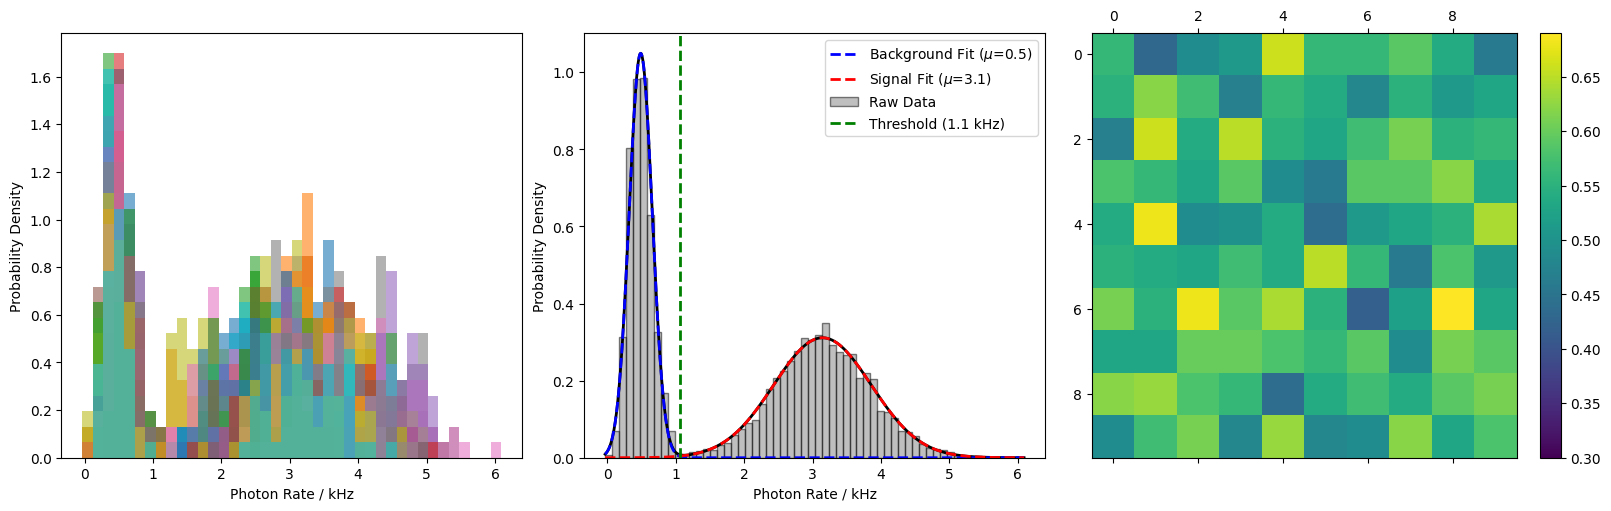

In [152]:
imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
photon_rates, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60)
survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions, array_shape, window_size=window)
print(f"Survival probability: {survival_probability*100:.4f} %")

In [309]:
# Get all of the images in the array "imgs1" and put them into a directory which I will write below. Name each image file image_0000.tif, image_0001.tif, image_0002.tif, etc. Overwrite all existing images in the directory
# Use the tifffile library to save the images. The directory is /home/user/data/images/
import os
import tifffile

output_dir = "C:\\Users\\tweez\\ColdMatter\\pytweezer\\Image Data\\5ms expo images\\"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for i, img in enumerate(imgs1):
    filename = f"{output_dir}/image_{i:04d}.tif"
    tifffile.imwrite(filename, img)

In [310]:
output_dir = "C:\\Users\\tweez\\ColdMatter\\pytweezer\\Image Data\\5ms expo backgrounds\\"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for i, img in enumerate(imgs2):
    filename = f"{output_dir}/image_{i:04d}.tif"
    tifffile.imwrite(filename, img)

In [312]:
output_dir = "C:\\Users\\tweez\\ColdMatter\\pytweezer\\Image Data\\1ms dark images\\"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for i, img in enumerate(imgs):
    filename = f"{output_dir}/image_{i:04d}.tif"
    tifffile.imwrite(filename, img)

### Imaging Optimisation - Imaging Fidelity and Survival

In [159]:
# Experiment and camera setup
n_iterations = 20
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

N_scan, M_scan = 10, 10

img_cool_vco_list = np.linspace(0.0, 4.0, N_scan)
img_cool_vva_list = np.linspace(0.4, 1.5, M_scan)

loading_prob_matrix = np.zeros((len(img_cool_vco_list), len(img_cool_vva_list)))
survival_prob_matrix = np.zeros((len(img_cool_vco_list), len(img_cool_vva_list)))
fidelity_matrix = np.zeros((len(img_cool_vco_list), len(img_cool_vva_list)))

print(f"Scanning tweezer imaging cooling VCO and VVA...")
for i,j in np.ndindex(len(img_cool_vco_list), len(img_cool_vva_list)):
    img_cool_vco = img_cool_vco_list[i]
    img_cool_vva = img_cool_vva_list[j]

    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
        "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
        "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
        "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
        "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
        "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
        "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
        "tImgCoolVCO1": img_cool_vco, "tImgCoolVVA1": img_cool_vva, "tImgCoolVCO2": img_cool_vco, "tImgCoolVVA2": img_cool_vva,
        "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
        "BackgroundDrop": 0})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=False, vmaxfactor=0.6, show_grid=True)
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]

    photon_rates, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60, verbose=False, show_histogram=False)

    mean_loading_probability = np.mean(loading_probabilities)
    survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions, array_shape, window_size=window)

    if fidelity > 0.90 and mean_loading_probability > 0.2:
        loading_prob_matrix[i, j] = mean_loading_probability
        survival_prob_matrix[i, j] = survival_probability
        fidelity_matrix[i, j] = fidelity
    else:
        loading_prob_matrix[i, j] = np.nan
        survival_prob_matrix[i, j] = np.nan
        fidelity_matrix[i, j] = np.nan

    print(f"Index ({i}, {j})  |  ImgCoolVCO = {img_cool_vco:.2f} V, ImgCoolVVA = {img_cool_vva:.2f} V  |  Mean Loading Probability = {mean_loading_probability:.4f}, Survival Probability = {survival_probability:.4f}, Fidelity = {fidelity:.4f}")

Scanning tweezer imaging cooling VCO and VVA...
Index (0, 0)  |  ImgCoolVCO = 0.00 V, ImgCoolVVA = 0.40 V  |  Mean Loading Probability = 0.4070, Survival Probability = 0.3977, Fidelity = 0.8037
Index (0, 1)  |  ImgCoolVCO = 0.00 V, ImgCoolVVA = 0.52 V  |  Mean Loading Probability = 0.3505, Survival Probability = 0.4101, Fidelity = 0.8288
Index (0, 2)  |  ImgCoolVCO = 0.00 V, ImgCoolVVA = 0.64 V  |  Mean Loading Probability = 0.4020, Survival Probability = 0.4191, Fidelity = 0.8156
Index (0, 3)  |  ImgCoolVCO = 0.00 V, ImgCoolVVA = 0.77 V  |  Mean Loading Probability = 0.3795, Survival Probability = 0.5554, Fidelity = 0.8296
Index (0, 4)  |  ImgCoolVCO = 0.00 V, ImgCoolVVA = 0.89 V  |  Mean Loading Probability = 0.3580, Survival Probability = 0.5302, Fidelity = 0.8037
Index (0, 5)  |  ImgCoolVCO = 0.00 V, ImgCoolVVA = 1.01 V  |  Mean Loading Probability = 0.3440, Survival Probability = 0.5584, Fidelity = 0.8443
Index (0, 6)  |  ImgCoolVCO = 0.00 V, ImgCoolVVA = 1.13 V  |  Mean Loading P

Optimal survival: ImgCoolVVA = 1.38 V, ImgCoolVCO = 2.67 V  |  Loading Probability = 0.5640, Survival Probability = 0.9351, Fidelity = 0.9456
Optimal fidelity: ImgCoolVVA = 1.50 V, ImgCoolVCO = 2.67 V  |  Loading Probability = 0.5530, Survival Probability = 0.9267, Fidelity = 0.9627
Optimal product: ImgCoolVVA = 1.50 V, ImgCoolVCO = 2.67 V  |  Loading Probability = 0.5530, Survival Probability = 0.9267, Fidelity = 0.9627


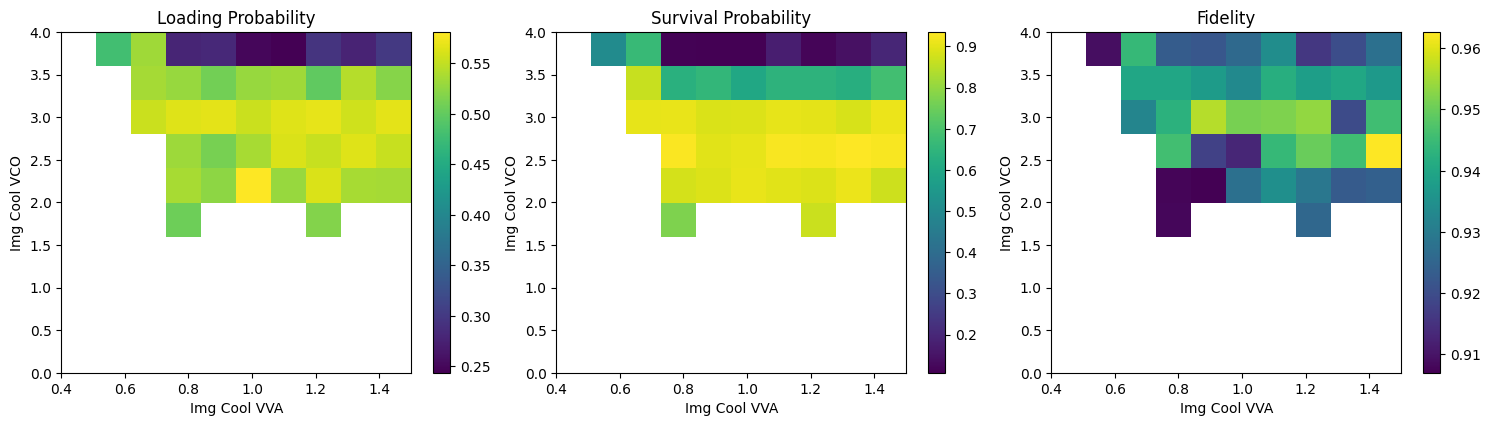

In [161]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
plt.tight_layout()

im1 = axs[0].imshow(loading_prob_matrix, cmap='viridis', extent=(img_cool_vva_list.min(), img_cool_vva_list.max(), img_cool_vco_list.min(), img_cool_vco_list.max()), origin='lower', aspect='auto')
axs[0].set_title('Loading Probability')
axs[0].set_xlabel('Img Cool VVA')
axs[0].set_ylabel('Img Cool VCO')
plt.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(survival_prob_matrix, cmap='viridis', extent=(img_cool_vva_list.min(), img_cool_vva_list.max(), img_cool_vco_list.min(), img_cool_vco_list.max()), origin='lower', aspect='auto')
axs[1].set_title('Survival Probability')
axs[1].set_xlabel('Img Cool VVA')
axs[1].set_ylabel('Img Cool VCO')
plt.colorbar(im2, ax=axs[1])

im3 = axs[2].imshow(fidelity_matrix, cmap='viridis', extent=(img_cool_vva_list.min(), img_cool_vva_list.max(), img_cool_vco_list.min(), img_cool_vco_list.max()), origin='lower', aspect='auto')
axs[2].set_title('Fidelity')
axs[2].set_xlabel('Img Cool VVA')
axs[2].set_ylabel('Img Cool VCO')
plt.colorbar(im3, ax=axs[2])

# Print the optimal parameters which maximise the survival probability, also print out the corresponding loading probability and fidelity. Note that the img_cool_vva_list and img_cool_vco_list are 1D arrays, so we need to find the indices of the maximum value in the survival_prob_matrix and then use those indices to get the corresponding VCO and VVA values.
max_index = np.unravel_index(np.nanargmax(survival_prob_matrix), survival_prob_matrix.shape)
optimal_img_cool_vco = img_cool_vco_list[max_index[0]]
optimal_img_cool_vva = img_cool_vva_list[max_index[1]]
optimal_loading_prob = loading_prob_matrix[max_index]
optimal_survival_prob = survival_prob_matrix[max_index]
optimal_fidelity = fidelity_matrix[max_index]
print(f"Optimal survival: ImgCoolVVA = {optimal_img_cool_vva:.2f} V, ImgCoolVCO = {optimal_img_cool_vco:.2f} V  |  Loading Probability = {optimal_loading_prob:.4f}, Survival Probability = {optimal_survival_prob:.4f}, Fidelity = {optimal_fidelity:.4f}")

# Repeat this but for the parameters which maximise the fidelity, also print out the corresponding loading probability and survival probability.
max_index_fidelity = np.unravel_index(np.nanargmax(fidelity_matrix), fidelity_matrix.shape)
optimal_img_cool_vco_fidelity = img_cool_vco_list[max_index_fidelity[0]]
optimal_img_cool_vva_fidelity = img_cool_vva_list[max_index_fidelity[1]]
optimal_loading_prob_fidelity = loading_prob_matrix[max_index_fidelity]
optimal_survival_prob_fidelity = survival_prob_matrix[max_index_fidelity]
optimal_fidelity_fidelity = fidelity_matrix[max_index_fidelity]
print(f"Optimal fidelity: ImgCoolVVA = {optimal_img_cool_vva_fidelity:.2f} V, ImgCoolVCO = {optimal_img_cool_vco_fidelity:.2f} V  |  Loading Probability = {optimal_loading_prob_fidelity:.4f}, Survival Probability = {optimal_survival_prob_fidelity:.4f}, Fidelity = {optimal_fidelity_fidelity:.4f}")

# Find the optimal parameters which maximise the product of the fidelity and the survival probability, also print out the corresponding loading probability. This is a good compromise between the two metrics.
product_matrix = fidelity_matrix * survival_prob_matrix
max_index_product = np.unravel_index(np.nanargmax(product_matrix), product_matrix.shape)
optimal_img_cool_vco_product = img_cool_vco_list[max_index_product[0]]
optimal_img_cool_vva_product = img_cool_vva_list[max_index_product[1]]
optimal_loading_prob_product = loading_prob_matrix[max_index_product]
optimal_survival_prob_product = survival_prob_matrix[max_index_product]
optimal_fidelity_product = fidelity_matrix[max_index_product]
print(f"Optimal product: ImgCoolVVA = {optimal_img_cool_vva_product:.2f} V, ImgCoolVCO = {optimal_img_cool_vco_product:.2f} V  |  Loading Probability = {optimal_loading_prob_product:.4f}, Survival Probability = {optimal_survival_prob_product:.4f}, Fidelity = {optimal_fidelity_product:.4f}")

In [162]:
ExpParams.set_parameter("tImgCoolVCO", 3.0)
ExpParams.set_parameter("tImgCoolVVA", 1.5)
ExpParams.save_parameters()

Parameter 'tImgCoolVCO' set to 3.0.
Parameter 'tImgCoolVVA' set to 1.5.
Parameters saved.


---
### Shim Coil Optimisation - Loading Probability 

In [109]:
# --- 1. Define the Experimental Search Space ---
dimensions = [  
    Real(name='tMOTShimXccValue', low=0.0, high=10.0),
    Real(name='tMOTShimYccValue', low=-5.0, high=5.0),
    Real(name='tMOTShimZccValue', low=-1.0, high=1.0)
]

# Experiment and camera setup
n_iterations = 50
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

@use_named_args(dimensions=dimensions)
def tweezer_exp_objective(tMOTShimXccValue, tMOTShimYccValue, tMOTShimZccValue):
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
            "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
            "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
            "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
            "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
            "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
            "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
            "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
            "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
            "tMOTShimXccValue": tMOTShimXccValue, "tMOTShimYccValue": tMOTShimYccValue, "tMOTShimZccValue": tMOTShimZccValue,
            "tMOTLoadingDuration": 10000, "PatternLength": 40000})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]

    _, loading_probabilities, _, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions, array_shape, threshold_detection=False, threshold=1.6, window_size=window, binning=60, verbose=False, show_histogram=False)
    mean_loading_probability = np.mean(loading_probabilities)
    measured_loss = 1.0 - mean_loading_probability

    print(f"Parameters: tMOTShimXccValue = {tMOTShimXccValue:.2f}, tMOTShimYccValue = {tMOTShimYccValue:.2f}, tMOTShimZccValue = {tMOTShimZccValue:.2f}  |  Mean Loading Probability = {mean_loading_probability:.4f}")
    return measured_loss

In [110]:
print("Starting Bayesian Optimization with dynamic exploration...")

n_calls = 50
n_initial_points = 10
xi_start = 0.100
xi_end = 0.001

opt = Optimizer(
    dimensions=dimensions,
    n_initial_points=n_initial_points,
    acq_func='EI',
    random_state=50
)

# Custom optimization loop
for i in range(n_calls):
    current_xi = xi_start - (xi_start - xi_end) * (i / (n_calls - 1))
    opt.acq_func_kwargs = {'xi': current_xi}
    suggested_params = opt.ask()
    loss = tweezer_exp_objective(suggested_params)
    result = opt.tell(suggested_params, loss)
    print(f"Iteration {i+1}/{n_calls} (xi = {current_xi:.4f})")
    print(f"  Current score: {(1-loss):.4f}")
    print(f"  Best score: {(1-result.fun):.4f}\n")

# --- 4. Analyze the Results ---
print("\n" + "="*40)
print("Optimization Complete!")
print("="*40)

high_score = 1 - result.fun
best_params = result.x

print(f"Best Parameters Found:")
for dim, value in zip(dimensions, best_params):
    print(f"  {dim.name}: {value:.4f}")

Starting Bayesian Optimization with dynamic exploration...
Parameters: tMOTShimXccValue = 1.29, tMOTShimYccValue = -4.26, tMOTShimZccValue = 0.22  |  Mean Loading Probability = 0.0032
Iteration 1/50 (xi = 0.1000)
  Current score: 0.0032
  Best score: 0.0032

Parameters: tMOTShimXccValue = 0.21, tMOTShimYccValue = -3.48, tMOTShimZccValue = 0.91  |  Mean Loading Probability = 0.0010
Iteration 2/50 (xi = 0.0980)
  Current score: 0.0010
  Best score: 0.0032

Parameters: tMOTShimXccValue = 8.05, tMOTShimYccValue = -2.56, tMOTShimZccValue = -0.35  |  Mean Loading Probability = 0.0160
Iteration 3/50 (xi = 0.0960)
  Current score: 0.0160
  Best score: 0.0160

Parameters: tMOTShimXccValue = 4.39, tMOTShimYccValue = -3.65, tMOTShimZccValue = 0.19  |  Mean Loading Probability = 0.0042
Iteration 4/50 (xi = 0.0939)
  Current score: 0.0042
  Best score: 0.0160

Parameters: tMOTShimXccValue = 9.78, tMOTShimYccValue = -4.11, tMOTShimZccValue = -0.41  |  Mean Loading Probability = 0.0086
Iteration 5/50

C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis_lean.py:360: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_rates[tot_photon_rates >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis_lean.py:362: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_rates[tot_photon_rates >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divid

Parameters: tMOTShimXccValue = 9.97, tMOTShimYccValue = -2.25, tMOTShimZccValue = 0.99  |  Mean Loading Probability = 0.0000
Iteration 14/50 (xi = 0.0737)
  Current score: 0.0000
  Best score: 0.2178

Parameters: tMOTShimXccValue = 0.00, tMOTShimYccValue = 3.93, tMOTShimZccValue = -1.00  |  Mean Loading Probability = 0.1188
Iteration 15/50 (xi = 0.0717)
  Current score: 0.1188
  Best score: 0.2178

Parameters: tMOTShimXccValue = 9.99, tMOTShimYccValue = -2.29, tMOTShimZccValue = -1.00  |  Mean Loading Probability = 0.0010
Iteration 16/50 (xi = 0.0697)
  Current score: 0.0010
  Best score: 0.2178



C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis_lean.py:363: RuntimeWarning: divide by zero encountered in scalar divide
  fidelity = norm.cdf((threshold - mu_sig) / np.sqrt(var_sig)) + (1 - norm.cdf((threshold - mu_bg) / np.sqrt(var_bg)))


Parameters: tMOTShimXccValue = 5.52, tMOTShimYccValue = 1.93, tMOTShimZccValue = 1.00  |  Mean Loading Probability = 0.0002
Iteration 17/50 (xi = 0.0677)
  Current score: 0.0002
  Best score: 0.2178

Parameters: tMOTShimXccValue = 6.68, tMOTShimYccValue = -4.56, tMOTShimZccValue = -1.00  |  Mean Loading Probability = 0.0040
Iteration 18/50 (xi = 0.0657)
  Current score: 0.0040
  Best score: 0.2178

Parameters: tMOTShimXccValue = 0.00, tMOTShimYccValue = 5.00, tMOTShimZccValue = -0.61  |  Mean Loading Probability = 0.1840
Iteration 19/50 (xi = 0.0636)
  Current score: 0.1840
  Best score: 0.2178

Parameters: tMOTShimXccValue = 3.75, tMOTShimYccValue = 3.35, tMOTShimZccValue = -0.66  |  Mean Loading Probability = 0.0500
Iteration 20/50 (xi = 0.0616)
  Current score: 0.0500
  Best score: 0.2178

Parameters: tMOTShimXccValue = 1.99, tMOTShimYccValue = -1.81, tMOTShimZccValue = -0.35  |  Mean Loading Probability = 0.1502
Iteration 21/50 (xi = 0.0596)
  Current score: 0.1502
  Best score: 0.

C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis_lean.py:360: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_rates[tot_photon_rates >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis_lean.py:362: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_rates[tot_photon_rates >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divid

Parameters: tMOTShimXccValue = 9.89, tMOTShimYccValue = 4.75, tMOTShimZccValue = 0.98  |  Mean Loading Probability = 0.0000
Iteration 35/50 (xi = 0.0313)
  Current score: 0.0000
  Best score: 0.5250

Parameters: tMOTShimXccValue = 0.04, tMOTShimYccValue = -4.67, tMOTShimZccValue = -0.30  |  Mean Loading Probability = 0.2670
Iteration 36/50 (xi = 0.0293)
  Current score: 0.2670
  Best score: 0.5250

Parameters: tMOTShimXccValue = 9.51, tMOTShimYccValue = 4.90, tMOTShimZccValue = -0.99  |  Mean Loading Probability = 0.0020
Iteration 37/50 (xi = 0.0273)
  Current score: 0.0020
  Best score: 0.5250

Parameters: tMOTShimXccValue = 0.10, tMOTShimYccValue = -4.80, tMOTShimZccValue = -0.68  |  Mean Loading Probability = 0.4086
Iteration 38/50 (xi = 0.0252)
  Current score: 0.4086
  Best score: 0.5250

Parameters: tMOTShimXccValue = 9.96, tMOTShimYccValue = -4.48, tMOTShimZccValue = 0.08  |  Mean Loading Probability = 0.0048
Iteration 39/50 (xi = 0.0232)
  Current score: 0.0048
  Best score: 0.

In [111]:
ExpParams.set_parameter("tMOTShimXccValue", best_params[0])
ExpParams.set_parameter("tMOTShimYccValue", best_params[1])
ExpParams.set_parameter("tMOTShimZccValue", best_params[2])
ExpParams.save_parameters()

Parameter 'tMOTShimXccValue' set to 0.017274499890946874.
Parameter 'tMOTShimYccValue' set to 1.38581476439688.
Parameter 'tMOTShimZccValue' set to -0.4844836103904361.
Parameters saved.


---
### Molasses Optimisation - Imaging Fidelity and Survival

In [105]:
# --- 1. Define the Experimental Search Space ---
dimensions = [  
    Real(name='tMolCoolVCO1', low=0.0, high=3.0),
    Real(name='tMolRepVCO1', low=0.0, high=5.0),             
    Real(name='tMolCoolVVA1', low=0.4, high=1.0),
    Real(name='tMolRepVVA1', low=0.4, high=1.0),
    Real(name='tMolCoolVCO2', low=0.0, high=3.0),
    Real(name='tMolRepVCO2', low=0.0, high=5.0),             
    Real(name='tMolCoolVVA2', low=0.4, high=1.0),
    Real(name='tMolRepVVA2', low=0.4, high=1.0),
]

# Experiment and camera setup
n_iterations = 50
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

@use_named_args(dimensions=dimensions)
def tweezer_exp_objective(tMolCoolVCO1, tMolRepVCO1, tMolCoolVVA1, tMolRepVVA1, tMolCoolVCO2, tMolRepVCO2, tMolCoolVVA2, tMolRepVVA2):

    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
            "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
            "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
            "tMolCoolVCO1": tMolCoolVCO1, "tMolRepVCO1": tMolRepVCO1, 
            "tMolCoolVVA1": tMolCoolVVA1, "tMolRepVVA1": tMolRepVVA1,
            "tMolCoolVCO2": tMolCoolVCO2, "tMolRepVCO2": tMolRepVCO2, 
            "tMolCoolVVA2": tMolCoolVVA2, "tMolRepVVA2": tMolRepVVA2,
            "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
            "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
            "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
            "BackgroundDrop": 0})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]

    _, loading_probabilities, _, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions, array_shape, threshold_detection=True, window_size=window, binning=60, verbose=False, show_histogram=False)
    mean_loading_probability = np.mean(loading_probabilities)
    survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions, array_shape, window_size=window)

    if fidelity > 0.90 and mean_loading_probability > 0.4:
        measured_loss = 1.0 - survival_probability * fidelity
    else:
        measured_loss = 1.0
        
    print(f"tMolCoolVCO1 = {tMolCoolVCO1:.2f} V, tMolRepVCO1 = {tMolRepVCO1:.2f} V, tMolCoolVVA1 = {tMolCoolVVA1:.2f} V, tMolRepVVA1 = {tMolRepVVA1:.2f} V")
    print(f"tMolCoolVCO2 = {tMolCoolVCO2:.2f} V, tMolRepVCO2 = {tMolRepVCO2:.2f} V, tMolCoolVVA2 = {tMolCoolVVA2:.2f} V, tMolRepVVA2 = {tMolRepVVA2:.2f} V")
    print(f"Mean Loading Probability = {mean_loading_probability:.4f}, Survival Probability = {survival_probability:.4f}, Fidelity = {fidelity:.4f}")
    print(f"Measured Loss = {measured_loss:.4f}")
    return measured_loss

In [107]:
print("Starting Bayesian Optimization with dynamic exploration...")

n_calls = 80
n_initial_points = 10
xi_start = 0.100
xi_end = 0.001

opt = Optimizer(
    dimensions=dimensions,
    n_initial_points=n_initial_points,
    acq_func='EI',
    random_state=50
)

# Custom optimization loop
for i in range(n_calls):
    current_xi = xi_start - (xi_start - xi_end) * (i / (n_calls - 1))
    opt.acq_func_kwargs = {'xi': current_xi}
    suggested_params = opt.ask()
    loss = tweezer_exp_objective(suggested_params)
    result = opt.tell(suggested_params, loss)
    print(f"Iteration {i+1}/{n_calls} (xi = {current_xi:.4f})")
    print(f"  Current score: {(1-loss):.4f}")
    print(f"  Best score: {(1-result.fun):.4f}\n")

# --- 4. Analyze the Results ---
print("\n" + "="*40)
print("Optimization Complete!")
print("="*40)

high_score = 1 - result.fun
best_params = result.x

print(f"Best Parameters Found:")
for dim, value in zip(dimensions, best_params):
    print(f"  {dim.name}: {value:.4f}")

Starting Bayesian Optimization with dynamic exploration...
tMolCoolVCO1 = 0.39 V, tMolRepVCO1 = 0.37 V, tMolCoolVVA1 = 0.77 V, tMolRepVVA1 = 0.41 V
tMolCoolVCO2 = 0.46 V, tMolRepVCO2 = 4.77 V, tMolCoolVVA2 = 0.88 V, tMolRepVVA2 = 0.55 V
Mean Loading Probability = 0.5404, Survival Probability = 0.8729, Fidelity = 0.9993
Measured Loss = 0.1277
Iteration 1/80 (xi = 0.1000)
  Current score: 0.8723
  Best score: 0.8723

tMolCoolVCO1 = 0.98 V, tMolRepVCO1 = 2.20 V, tMolCoolVVA1 = 0.48 V, tMolRepVVA1 = 0.76 V
tMolCoolVCO2 = 2.93 V, tMolRepVCO2 = 0.44 V, tMolCoolVVA2 = 0.58 V, tMolRepVVA2 = 0.54 V
Mean Loading Probability = 0.1425, Survival Probability = 0.9311, Fidelity = 0.9999
Measured Loss = 1.0000
Iteration 2/80 (xi = 0.0987)
  Current score: 0.0000
  Best score: 0.8723

tMolCoolVCO1 = 1.55 V, tMolRepVCO1 = 0.23 V, tMolCoolVVA1 = 0.56 V, tMolRepVVA1 = 0.80 V
tMolCoolVCO2 = 2.37 V, tMolRepVCO2 = 1.82 V, tMolCoolVVA2 = 0.47 V, tMolRepVVA2 = 0.50 V
Mean Loading Probability = 0.1625, Survival

In [121]:
for dim, value in zip(dimensions, best_params):
    print(f"  {dim.name}: {value:.4f}")
    ExpParams.set_parameter(dim.name, value)
    ExpParams.save_parameters()

  tMolCoolVCO1: 1.3143
  tMolRepVCO1: 3.4691
  tMolCoolVVA1: 0.6741
  tMolRepVVA1: 0.5966
  tMolCoolVCO2: 0.0499
  tMolRepVCO2: 0.0042
  tMolCoolVVA2: 0.7166
  tMolRepVVA2: 0.7327


In [122]:
ExpParams.load_parameters()

{'motmaster_parameters': {'tMOTLoadCoolVCO': 4.2631578947368425,
  'tMOTLoadRepVCO': 1.8421052631578947,
  'tMolCoolVCO1': 1.3142667720116488,
  'tMolRepVCO1': 3.469121980074304,
  'tMolCoolVVA1': 0.6741410196462048,
  'tMolRepVVA1': 0.5966242727734119,
  'tMolCoolVCO2': 0.04994064431353901,
  'tMolRepVCO2': 0.0041732932174601,
  'tMolCoolVVA2': 0.7166101848896118,
  'tMolRepVVA2': 0.7327236299505516,
  'tMOTShimXccValue': -1.9142550713624034,
  'tMOTShimYccValue': -2.3911971152849727,
  'tMOTShimZccValue': -0.22717632319839043,
  'tMOTLoadRepVVA': 0.6526315789473685,
  'tMOTLoadCoolVVA': 0.9210526315789475,
  'tImgCoolVCO': 1.33,
  'tImgCoolVVA': 0.89},
 'misc_parameters': {'rep_vco_resonance': 4.473684210526316,
  'cool_vco_resonance': 4.789473684210526}}

In [120]:
ExpParams.add_parameter("tMolCoolVCO1", 1.3143, category='motmaster_parameters')
ExpParams.save_parameters()
ExpParams.load_parameters()

{'motmaster_parameters': {'tMOTLoadCoolVCO': 4.2631578947368425,
  'tMOTLoadRepVCO': 1.8421052631578947,
  'tMolCoolVCO1': 1.3143,
  'tMolRepVCO1': 3.11082537869259,
  'tMolCoolVVA1': 1.0,
  'tMolRepVVA1': 0.5284897101402367,
  'tMolCoolVCO2': 0.0,
  'tMolRepVCO2': 3.259016009127741,
  'tMolCoolVVA2': 0.9895836703797966,
  'tMolRepVVA2': 0.7590677019962364,
  'tMOTShimXccValue': -1.9142550713624034,
  'tMOTShimYccValue': -2.3911971152849727,
  'tMOTShimZccValue': -0.22717632319839043,
  'tMOTLoadRepVVA': 0.6526315789473685,
  'tMOTLoadCoolVVA': 0.9210526315789475,
  'tImgCoolVCO': 1.33,
  'tImgCoolVVA': 0.89},
 'misc_parameters': {'rep_vco_resonance': 4.473684210526316,
  'cool_vco_resonance': 4.789473684210526}}

In [313]:
slm.close()
hamcam.close()
motcam.close()

SLM 1 closed.
ImagEM X2 camera closed.
Thorlabs TLCamera - motcam - closed.
